# 数据统计

In [58]:
import pandas as pd
import json
import networkx as nx
import matplotlib.pyplot as plt
import math

from collections import defaultdict

In [59]:
import sys
sys.path.append('..')

## 原始数据

In [60]:
df_raw = pd.read_excel('data/mayday_songs.xlsx', sheet_name='Sheet1')
df_raw['song_name'] = df_raw['song_name'].astype(str)
df_raw

,album_order,album_id,album_name,album_type,release_date,song_order,song_id,song_name,album_fixed,has_lyric,is_duplicate
0,1,38315,第一张创作专辑,录音室专辑,1999-07-07,1,386925,疯狂世界,第一张创作专辑,1,0
1,1,38315,第一张创作专辑,录音室专辑,1999-07-07,2,386927,拥抱,第一张创作专辑,1,0
2,1,38315,第一张创作专辑,录音室专辑,1999-07-07,3,386929,透露,第一张创作专辑,1,0
3,1,38315,第一张创作专辑,录音室专辑,1999-07-07,4,386930,生活,第一张创作专辑,1,0
4,1,38315,第一张创作专辑,录音室专辑,1999-07-07,5,386931,爱情的模样,第一张创作专辑,1,0
...,...,...,...,...,...,...,...,...,...,...,...
185,11,2740205,步步 自选作品辑,精选辑,2013-12-30,26,28181124,雌雄同体,步步 自选作品辑,1,1
186,11,2740205,步步 自选作品辑,精选辑,2013-12-30,27,28181126,生命有一种绝对,步步 自选作品辑,1,1
187,11,2740205,步步 自选作品辑,精选辑,2013-12-30,28,28181128,诺亚方舟,步步 自选作品辑,1,1
188,11,2740205,步步 自选作品辑,精选辑,2013-12-30,29,28181130,我心中尚未崩坏的地方,步步 自选作品辑,1,1


In [61]:
df_lyric_raw = pd.read_csv('output/mayday_lyric_word.csv')
df_lyric_raw

,song_id,word,pos,freq,album_order,album_id,album_name,album_type,release_date,song_order,song_name,album_fixed,has_lyric,is_duplicate,song_name_fixed
0,386925,我,r,18,1.0,38315.0,第一张创作专辑,录音室专辑,1999-07-07,1.0,疯狂世界,第一张创作专辑,1.0,0.0,疯狂世界
1,386925,好想,v,18,1.0,38315.0,第一张创作专辑,录音室专辑,1999-07-07,1.0,疯狂世界,第一张创作专辑,1.0,0.0,疯狂世界
2,386925,那么,r,12,1.0,38315.0,第一张创作专辑,录音室专辑,1999-07-07,1.0,疯狂世界,第一张创作专辑,1.0,0.0,疯狂世界
3,386925,多,m,12,1.0,38315.0,第一张创作专辑,录音室专辑,1999-07-07,1.0,疯狂世界,第一张创作专辑,1.0,0.0,疯狂世界
4,386925,的,uj,12,1.0,38315.0,第一张创作专辑,录音室专辑,1999-07-07,1.0,疯狂世界,第一张创作专辑,1.0,0.0,疯狂世界
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13057,28181110,长大,v,1,11.0,2740205.0,步步 自选作品辑,精选辑,2013-12-30,19.0,盛夏光年,步步 自选作品辑,1.0,0.0,盛夏光年
13058,28181110,难道,d,1,11.0,2740205.0,步步 自选作品辑,精选辑,2013-12-30,19.0,盛夏光年,步步 自选作品辑,1.0,0.0,盛夏光年
13059,28181110,人,n,1,11.0,2740205.0,步步 自选作品辑,精选辑,2013-12-30,19.0,盛夏光年,步步 自选作品辑,1.0,0.0,盛夏光年
13060,28181110,必经,d,1,11.0,2740205.0,步步 自选作品辑,精选辑,2013-12-30,19.0,盛夏光年,步步 自选作品辑,1.0,0.0,盛夏光年


## 数据处理

In [5]:
def clear_lyric(df):
    # 曲目，专辑添加唯一id
    df_lyric = df.copy()
    df_lyric['song_id_unique'] = 'song' + df_lyric['song_id'].astype(str)
    df_album_fixed = df_lyric[['album_id', 'album_fixed']].drop_duplicates(subset=['album_fixed'], keep='first').reset_index(drop=True)
    df_album_fixed['album_id_unique'] = 'album' + df_album_fixed['album_id'].astype(int).astype(str)
    df_album_fixed = df_album_fixed[['album_id_unique', 'album_fixed']]
    df_lyric= df_lyric.merge(df_album_fixed, on='album_fixed', how='left')
    # 词唯一id
    df_words = df_lyric[['word', 'pos']].drop_duplicates().reset_index(drop=False)
    df_words['word_id'] = 'word' + df_words['index'].astype(str)
    df_words = df_words.drop('index', axis=1).reset_index(drop=True)
    df_lyric = df_lyric.merge(df_words, on=['word', 'pos'], how='left')
    return df_lyric

df_lyric = clear_lyric(df_lyric_raw)
df_lyric

,song_id,word,pos,freq,album_order,album_id,album_name,album_type,release_date,song_order,song_name,album_fixed,has_lyric,is_duplicate,song_name_fixed,song_id_unique,album_id_unique,word_id
0,386925,我,r,18,1.0,38315.0,第一张创作专辑,录音室专辑,1999-07-07,1.0,疯狂世界,第一张创作专辑,1.0,0.0,疯狂世界,song386925,album38315,word0
1,386925,好想,v,18,1.0,38315.0,第一张创作专辑,录音室专辑,1999-07-07,1.0,疯狂世界,第一张创作专辑,1.0,0.0,疯狂世界,song386925,album38315,word1
2,386925,那么,r,12,1.0,38315.0,第一张创作专辑,录音室专辑,1999-07-07,1.0,疯狂世界,第一张创作专辑,1.0,0.0,疯狂世界,song386925,album38315,word2
3,386925,多,m,12,1.0,38315.0,第一张创作专辑,录音室专辑,1999-07-07,1.0,疯狂世界,第一张创作专辑,1.0,0.0,疯狂世界,song386925,album38315,word3
4,386925,的,uj,12,1.0,38315.0,第一张创作专辑,录音室专辑,1999-07-07,1.0,疯狂世界,第一张创作专辑,1.0,0.0,疯狂世界,song386925,album38315,word4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13057,28181110,长大,v,1,11.0,2740205.0,步步 自选作品辑,精选辑,2013-12-30,19.0,盛夏光年,步步 自选作品辑,1.0,0.0,盛夏光年,song28181110,album2740205,word2203
13058,28181110,难道,d,1,11.0,2740205.0,步步 自选作品辑,精选辑,2013-12-30,19.0,盛夏光年,步步 自选作品辑,1.0,0.0,盛夏光年,song28181110,album2740205,word5018
13059,28181110,人,n,1,11.0,2740205.0,步步 自选作品辑,精选辑,2013-12-30,19.0,盛夏光年,步步 自选作品辑,1.0,0.0,盛夏光年,song28181110,album2740205,word41
13060,28181110,必经,d,1,11.0,2740205.0,步步 自选作品辑,精选辑,2013-12-30,19.0,盛夏光年,步步 自选作品辑,1.0,0.0,盛夏光年,song28181110,album2740205,word13060


## 专辑数据

In [62]:
df_album = df_raw[[
    'album_id', 'album_name', 'album_type', 'release_date', 'album_fixed'
]].copy()
df_album['release_date'] = df_album['release_date'].astype(str)
df_album = df_album.drop_duplicates().reset_index()
df_album

,index,album_id,album_name,album_type,release_date,album_fixed
0,0,38315,第一张创作专辑,录音室专辑,1999-07-07,第一张创作专辑
1,12,38308,爱情万岁,录音室专辑,2000-07-07,爱情万岁
2,24,38297,人生海海,录音室专辑,2001-07-06,人生海海
3,36,38276,时光机,录音室专辑,2003-11-11,时光机
4,51,38259,神的孩子都在跳舞,录音室专辑,2004-11-05,神的孩子都在跳舞
5,64,38241,为爱而生,录音室专辑,2006-12-29,为爱而生
6,77,38235,后青春期的诗,录音室专辑,2008-10-23,后青春期的诗
7,89,2040001,第二人生 (明日版),录音室专辑,2011-12-16,第二人生
8,103,38214,第二人生 (末日版),录音室专辑,2011-12-16,第二人生
9,117,34746073,自传,录音室专辑,2016-07-21,自传


In [63]:
# 歌曲计数
songs_num = df_raw['album_name'].value_counts()
songs_num

album_name
知足 最真杰作选      30
步步 自选作品辑      30
时光机           15
第二人生 (明日版)    14
第二人生 (末日版)    14
神的孩子都在跳舞      13
为爱而生          13
自传            13
第一张创作专辑       12
爱情万岁          12
人生海海          12
后青春期的诗        12
Name: count, dtype: int64

In [65]:
df_raw['album_name'].unique()

array(['第一张创作专辑', '爱情万岁', '人生海海', '时光机', '神的孩子都在跳舞', '为爱而生', '后青春期的诗',
       '第二人生 (明日版)', '第二人生 (末日版)', '自传', '知足 最真杰作选', '步步 自选作品辑'],
      dtype=object)

In [8]:
# 纯音乐数量
instrumental_num = df_raw[df_raw['has_lyric'] ==
                          0]['album_name'].value_counts()
instrumental_num

album_name
为爱而生          2
神的孩子都在跳舞      1
第二人生 (明日版)    1
第二人生 (末日版)    1
知足 最真杰作选      1
Name: count, dtype: int64

In [9]:
# 新歌数量
new_songs_num = df_raw[df_raw['is_duplicate'] ==
                       0]['album_name'].value_counts()
new_songs_num

album_name
时光机           15
第二人生 (明日版)    14
神的孩子都在跳舞      13
为爱而生          13
自传            13
第一张创作专辑       12
爱情万岁          12
人生海海          12
后青春期的诗        12
知足 最真杰作选      11
步步 自选作品辑       7
第二人生 (末日版)     2
Name: count, dtype: int64

In [10]:
df_album = df_album.merge(songs_num, on='album_name', how='left').rename(columns={'count': 'songs_num'})
df_album

,index,album_id,album_name,album_type,release_date,album_fixed,songs_num
0,0,38315,第一张创作专辑,录音室专辑,1999-07-07,第一张创作专辑,12
1,12,38308,爱情万岁,录音室专辑,2000-07-07,爱情万岁,12
2,24,38297,人生海海,录音室专辑,2001-07-06,人生海海,12
3,36,38276,时光机,录音室专辑,2003-11-11,时光机,15
4,51,38259,神的孩子都在跳舞,录音室专辑,2004-11-05,神的孩子都在跳舞,13
5,64,38241,为爱而生,录音室专辑,2006-12-29,为爱而生,13
6,77,38235,后青春期的诗,录音室专辑,2008-10-23,后青春期的诗,12
7,89,2040001,第二人生 (明日版),录音室专辑,2011-12-16,第二人生,14
8,103,38214,第二人生 (末日版),录音室专辑,2011-12-16,第二人生,14
9,117,34746073,自传,录音室专辑,2016-07-21,自传,13


In [11]:
df_album = df_album.merge(
    instrumental_num, on='album_name',
    how='left').rename(columns={'count': 'instrumental_num'}).fillna(0)
df_album 

,index,album_id,album_name,album_type,release_date,album_fixed,songs_num,instrumental_num
0,0,38315,第一张创作专辑,录音室专辑,1999-07-07,第一张创作专辑,12,0.0
1,12,38308,爱情万岁,录音室专辑,2000-07-07,爱情万岁,12,0.0
2,24,38297,人生海海,录音室专辑,2001-07-06,人生海海,12,0.0
3,36,38276,时光机,录音室专辑,2003-11-11,时光机,15,0.0
4,51,38259,神的孩子都在跳舞,录音室专辑,2004-11-05,神的孩子都在跳舞,13,1.0
5,64,38241,为爱而生,录音室专辑,2006-12-29,为爱而生,13,2.0
6,77,38235,后青春期的诗,录音室专辑,2008-10-23,后青春期的诗,12,0.0
7,89,2040001,第二人生 (明日版),录音室专辑,2011-12-16,第二人生,14,1.0
8,103,38214,第二人生 (末日版),录音室专辑,2011-12-16,第二人生,14,1.0
9,117,34746073,自传,录音室专辑,2016-07-21,自传,13,0.0


In [12]:
df_album = df_album.merge(
    new_songs_num, on='album_name',
    how='left').rename(columns={'count': 'new_songs_num'}).fillna(0)
df_album 

,index,album_id,album_name,album_type,release_date,album_fixed,songs_num,instrumental_num,new_songs_num
0,0,38315,第一张创作专辑,录音室专辑,1999-07-07,第一张创作专辑,12,0.0,12
1,12,38308,爱情万岁,录音室专辑,2000-07-07,爱情万岁,12,0.0,12
2,24,38297,人生海海,录音室专辑,2001-07-06,人生海海,12,0.0,12
3,36,38276,时光机,录音室专辑,2003-11-11,时光机,15,0.0,15
4,51,38259,神的孩子都在跳舞,录音室专辑,2004-11-05,神的孩子都在跳舞,13,1.0,13
5,64,38241,为爱而生,录音室专辑,2006-12-29,为爱而生,13,2.0,13
6,77,38235,后青春期的诗,录音室专辑,2008-10-23,后青春期的诗,12,0.0,12
7,89,2040001,第二人生 (明日版),录音室专辑,2011-12-16,第二人生,14,1.0,14
8,103,38214,第二人生 (末日版),录音室专辑,2011-12-16,第二人生,14,1.0,2
9,117,34746073,自传,录音室专辑,2016-07-21,自传,13,0.0,13


In [13]:
album_dict = df_album.to_dict(orient='records')
with open('output/album_data.json', 'w', encoding='utf-8') as f:
    json.dump(album_dict, f, ensure_ascii=False, indent=4)


In [14]:
df_album['album_fixed'].tolist()

['第一张创作专辑',
 '爱情万岁',
 '人生海海',
 '时光机',
 '神的孩子都在跳舞',
 '为爱而生',
 '后青春期的诗',
 '第二人生',
 '第二人生',
 '自传',
 '知足 最真杰作选',
 '步步 自选作品辑']

## 曲目数据

In [15]:
df_songs = df_raw[df_raw['is_duplicate'] == 0][[
    'album_fixed', 'song_name'
]].drop_duplicates().reset_index(drop=True).copy()
df_songs

,album_fixed,song_name
0,第一张创作专辑,疯狂世界
1,第一张创作专辑,拥抱
2,第一张创作专辑,透露
3,第一张创作专辑,生活
4,第一张创作专辑,爱情的模样
...,...,...
131,步步 自选作品辑,洋葱 (2013新录制作品)
132,步步 自选作品辑,入阵曲
133,步步 自选作品辑,离开地球表面
134,步步 自选作品辑,你是唯一 (2013新录制作品)


In [16]:
songs_dict = df_songs.to_dict(orient='records')
with open('output/songs_data.json', 'w', encoding='utf-8') as f:
    json.dump(songs_dict, f, ensure_ascii=False, indent=4)

# 分词数据
名词： n, w
动词： v
形容词： v

In [17]:
df_lyric_raw

,song_id,word,pos,freq,album_order,album_id,album_name,album_type,release_date,song_order,song_name,album_fixed,has_lyric,is_duplicate,song_name_fixed
0,386925,我,r,18,1.0,38315.0,第一张创作专辑,录音室专辑,1999-07-07,1.0,疯狂世界,第一张创作专辑,1.0,0.0,疯狂世界
1,386925,好想,v,18,1.0,38315.0,第一张创作专辑,录音室专辑,1999-07-07,1.0,疯狂世界,第一张创作专辑,1.0,0.0,疯狂世界
2,386925,那么,r,12,1.0,38315.0,第一张创作专辑,录音室专辑,1999-07-07,1.0,疯狂世界,第一张创作专辑,1.0,0.0,疯狂世界
3,386925,多,m,12,1.0,38315.0,第一张创作专辑,录音室专辑,1999-07-07,1.0,疯狂世界,第一张创作专辑,1.0,0.0,疯狂世界
4,386925,的,uj,12,1.0,38315.0,第一张创作专辑,录音室专辑,1999-07-07,1.0,疯狂世界,第一张创作专辑,1.0,0.0,疯狂世界
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13057,28181110,长大,v,1,11.0,2740205.0,步步 自选作品辑,精选辑,2013-12-30,19.0,盛夏光年,步步 自选作品辑,1.0,0.0,盛夏光年
13058,28181110,难道,d,1,11.0,2740205.0,步步 自选作品辑,精选辑,2013-12-30,19.0,盛夏光年,步步 自选作品辑,1.0,0.0,盛夏光年
13059,28181110,人,n,1,11.0,2740205.0,步步 自选作品辑,精选辑,2013-12-30,19.0,盛夏光年,步步 自选作品辑,1.0,0.0,盛夏光年
13060,28181110,必经,d,1,11.0,2740205.0,步步 自选作品辑,精选辑,2013-12-30,19.0,盛夏光年,步步 自选作品辑,1.0,0.0,盛夏光年


In [18]:
def word_count_by_pos(df, pos, words_num=30, is_starts_with=True):
    if is_starts_with:
        word_cnt = df[df['pos'].str.startswith(
            pos, na=False)]['word'].value_counts().reset_index()
        word_sum = df[df['pos'].str.startswith(
            pos, na=False)].groupby('word')['freq'].sum().reset_index()
    else:
        word_cnt = df[df['pos']==pos]['word'].value_counts().reset_index()
        word_sum = df[df['pos']==pos].groupby('word')['freq'].sum().reset_index()
    if words_num:
        res = word_cnt.head(words_num).merge(word_sum, on='word', how='left')
    else:
        res = word_cnt.merge(word_sum, on='word', how='left')
    res['order'] = 100 - res.index
    res = res.rename(columns={
        'count': 'songs_num',
    })
    return res

In [19]:
pos_list = ['n', 'v', 'a']
words_dict = defaultdict(dict)
for pos in pos_list:
    res_df = word_count_by_pos(df_lyric_raw, pos, 70)
    words_dict[pos] = res_df.to_dict('list')

with open('output/words_data.json', 'w', encoding='utf-8') as f:
    json.dump(words_dict, f, ensure_ascii=False, indent=4)

# 词图

## 二分图布局

In [20]:
# 120度弧线布局
def generate_symmetric_bipartite_layout(nodes):
    coords = {}
    
    # --- 1. 参数定义 ---
    # 定义两条对称弧线的几何参数
    arc_radius = 800
    arc_span = math.pi / 1.5  # 约 120 度
    # 计算弧线的垂直跨度 (用于决定 Word 长度)
    arc_vertical_span = 2 * arc_radius * math.sin(arc_span / 2)
    
    # --- 2. Word 节点 (画布中央直线) ---
    word_nodes = sorted([n for n in nodes if n['type'] == 'word'], key=lambda x: x['degree'], reverse=True)
    num_words = len(word_nodes)
    
    # 长度为弧线跨度的 90%
    target_word_height = arc_vertical_span * 0.9
    word_y_gap = target_word_height / (num_words - 1) if num_words > 1 else 0

    for i, node in enumerate(word_nodes):
        # 中心向两端扩散逻辑: 0->0, 1->1, 2->-1, 3->2...
        rank = (i + 1) // 2
        direction = 1 if i % 2 != 0 else -1
        if i == 0: direction = 0
        
        # Word 位于 x=0，且在 y 轴居中
        coords[node['id']] = (0, round(rank * direction * word_y_gap, 2))

    # --- 3. Song 节点 (两侧对称弧线) ---
    song_nodes = [n for n in nodes if n['type'] == 'song']
    mid_idx = len(song_nodes) // 2
    # 将 Song 平均分为两组：左侧弧和右侧弧
    song_columns = [song_nodes[:mid_idx], song_nodes[mid_idx:]]
    
    # 弧线布局配置：[左侧弧, 右侧弧]
    # 左侧弧圆心在正 X，向左弯曲；右侧弧圆心在负 X，向右弯曲
    configs = [
        {"center_x": 0, "direction": -1}, # 右侧弧 (位于 Word 右侧)
        {"center_x": 0, "direction": 1}  # 左侧弧 (位于 Word 左侧)
    ]

    for col_idx, col_items in enumerate(song_columns):
        config = configs[col_idx]
        num_in_col = len(col_items)
        if num_in_col == 0: continue
        
        for row_idx, node in enumerate(col_items):
            # 从上到下均匀分布角度
            if num_in_col > 1:
                angle = (arc_span / 2) - (row_idx / (num_in_col - 1)) * arc_span
            else:
                angle = 0
            
            # 计算坐标
            # cos(angle) 决定 X 偏移，direction 决定是在圆心左侧还是右侧
            x = config["center_x"] + config["direction"] * (arc_radius * math.cos(angle))
            y = arc_radius * math.sin(angle)
            coords[node['id']] = (round(x, 2), round(y, 2))
            
    return coords


In [21]:
# 112度弧形布局
def generate_embracing_layout(nodes):
    coords = {}
    
    # --- 1. 几何参数设定 ---
    arc_radius = 800           # 半径
    arc_span = math.pi / 1.6   # 弧度张角 (约112度)
    # 弧开口端点距离中心直线的水平间距
    horizontal_gap = 300       
    
    # 计算弧线端点的 Y 轴跨度 (用于对齐 Word)
    # y = r * sin(theta)
    arc_half_height = arc_radius * math.sin(arc_span / 2)
    arc_total_height = 2 * arc_half_height
    
    # --- 2. Word 节点 (居中直线) ---
    word_nodes = sorted([n for n in nodes if n['type'] == 'word'], key=lambda x: x['degree'], reverse=True)
    num_words = len(word_nodes)
    
    # 长度为弧垂直跨度的 90%
    target_word_height = arc_total_height * 0.9
    word_y_gap = target_word_height / (num_words - 1) if num_words > 1 else 0

    for i, node in enumerate(word_nodes):
        # 中心扩散排序
        rank = (i + 1) // 2
        direction = 1 if i % 2 != 0 else -1
        if i == 0: direction = 0
        coords[node['id']] = (0, round(rank * direction * word_y_gap, 2))

    # --- 3. Song 节点 (开口向内的对称弧线) ---
    song_nodes = [n for n in nodes if n['type'] == 'song']
    mid_idx = len(song_nodes) // 2
    song_groups = [song_nodes[:mid_idx], song_nodes[mid_idx:]]
    
    # 配置说明：
    # 为了让开口面向直线 (x=0)：
    # 左侧弧的圆心要在右侧，x 坐标为 (horizontal_gap + radius * cos(half_span))
    # 右侧弧的圆心要在左侧，x 坐标为 -(horizontal_gap + radius * cos(half_span))
    
    # 计算圆心位置，使得弧的端点正好落在 horizontal_gap 线上
    edge_x_offset = arc_radius * math.cos(arc_span / 2)
    center_x_pos = horizontal_gap + edge_x_offset

    side_configs = [
        {"c_x": 0, "dir": 1, "name": "Right"}, # 右侧弧，圆心在左，向右弯
        {"c_x": 0, "dir": -1, "name": "Left"}   # 左侧弧，圆心在右，向左弯
    ]

    for col_idx, col_items in enumerate(song_groups):
        conf = side_configs[col_idx]
        num_in_col = len(col_items)
        
        for row_idx, node in enumerate(col_items):
            # 角度分布
            angle = (arc_span / 2) - (row_idx / (num_in_col - 1)) * arc_span if num_in_col > 1 else 0
            
            # 计算 X: 圆心 + 方向 * (半径 * cos(角度))
            x = conf["c_x"] + conf["dir"] * (arc_radius * math.cos(angle))
            y = arc_radius * math.sin(angle)
            coords[node['id']] = (round(x, 2), round(y, 2))
            
    return coords


## 数据处理

In [23]:
# 歌曲表
df_songs = df_lyric[['song_id', 'song_name', 'album_id', 'album_fixed', 'song_id_unique', 'album_id_unique']].drop_duplicates(subset=['song_id', 'album_fixed'], keep='first').reset_index(drop=True)
df_songs

,song_id,song_name,album_id,album_fixed,song_id_unique,album_id_unique
0,386925,疯狂世界,38315.0,第一张创作专辑,song386925,album38315
1,386927,拥抱,38315.0,第一张创作专辑,song386927,album38315
2,386929,透露,38315.0,第一张创作专辑,song386929,album38315
3,386930,生活,38315.0,第一张创作专辑,song386930,album38315
4,386931,爱情的模样,38315.0,第一张创作专辑,song386931,album38315
...,...,...,...,...,...,...
125,28181109,洋葱 (2013新录制作品),2740205.0,步步 自选作品辑,song28181109,album2740205
126,28181113,入阵曲,2740205.0,步步 自选作品辑,song28181113,album2740205
127,28181121,离开地球表面,2740205.0,步步 自选作品辑,song28181121,album2740205
128,28181104,你是唯一 (2013新录制作品),2740205.0,步步 自选作品辑,song28181104,album2740205


In [24]:
# 特定词性的数据集
def get_subset_data(df_lyric_raw, pos, words_num, is_starts_with):
    df_lyric = clear_lyric(df_lyric_raw)
    words_set = word_count_by_pos(df_lyric_raw, pos=pos, words_num=words_num, is_starts_with=is_starts_with)
    df_lyric_subset = df_lyric[df_lyric['pos'].str.startswith(pos, na=False)] if is_starts_with else df_lyric[df_lyric['pos'] == pos]
    df_lyric_subset = df_lyric_subset[df_lyric_subset['word'].isin(words_set['word'].tolist())].reset_index(drop=True)
    return df_lyric_subset

## json数据输出

In [27]:
def get_word_subset_graph(G_words_subset, df_lyric_subset):    
    word_graph_dict = defaultdict(list)
    words_degree = G_words_subset.degree
    nodes_subset = []
    for n in G_words_subset.nodes():
        n_dict = {
            'id': n,
            'degree': words_degree[n],
            'type': 'word' if 'word' in n else 'song',
        }
        nodes_subset.append(n_dict)
    pos = generate_embracing_layout(nodes_subset)
    for node in G_words_subset.nodes:
        nodes_dict = defaultdict(str)
        nodes_dict['id'] = node
        nodes_dict['size'] = words_degree[node]
        nodes_dict['x'] = pos[node][0]
        nodes_dict['y'] = pos[node][1]
        if 'word' in node:
            nodes_dict['label'] = df_lyric_subset[df_lyric_subset['word_id'] == node]['word'].values[0]
            nodes_dict['node_type'] = 'word'
            nodes_dict['album_id'] = ""
            nodes_dict['album'] = ""
            nodes_dict['data'] ={ 'cluster': '词' } 
        elif 'song' in node:
            nodes_dict['label'] = df_lyric_subset[df_lyric_subset['song_id_unique'] == node]['song_name'].values[0]
            nodes_dict['node_type'] = 'song'
            nodes_dict['album_id'] = df_lyric_subset[df_lyric_subset['song_id_unique'] == node]['album_id_unique'].values[0]
            nodes_dict['album'] = df_lyric_subset[df_lyric_subset['song_id_unique'] == node]['album_fixed'].values[0]
            nodes_dict['data'] ={ 'cluster': df_lyric_subset[df_lyric_subset['song_id_unique'] == node]['album_fixed'].values[0] } 
        word_graph_dict['nodes'].append(nodes_dict)
    for edeg in G_words_subset.edges:
        edges_dict = defaultdict(str)
        edges_dict['source'] = edeg[0]
        edges_dict['target'] = edeg[1]
        for i in edeg:
            if 'song' in i:
                edges_dict['album'] = df_lyric_subset[df_lyric_subset['song_id_unique'] == i]['album_fixed'].values[0]
            else:
                edges_dict['album'] = ""
            
        word_graph_dict['edges'].append(edges_dict)
    return word_graph_dict

In [52]:
df_lyric = clear_lyric(df_lyric_raw)

In [53]:
df_lyric_subset = get_subset_data(df_lyric_raw, 'a', words_num=50, is_starts_with=True)
df_lyric_subset

,song_id,word,pos,freq,album_order,album_id,album_name,album_type,release_date,song_order,song_name,album_fixed,has_lyric,is_duplicate,song_name_fixed,song_id_unique,album_id_unique,word_id
0,386925,疯狂,a,8,1.0,38315.0,第一张创作专辑,录音室专辑,1999-07-07,1.0,疯狂世界,第一张创作专辑,1.0,0.0,疯狂世界,song386925,album38315,word9
1,386927,远,a,2,1.0,38315.0,第一张创作专辑,录音室专辑,1999-07-07,2.0,拥抱,第一张创作专辑,1.0,0.0,拥抱,song386927,album38315,word89
2,386929,完美,a,3,1.0,38315.0,第一张创作专辑,录音室专辑,1999-07-07,3.0,透露,第一张创作专辑,1.0,0.0,透露,song386929,album38315,word165
3,386929,突然,ad,3,1.0,38315.0,第一张创作专辑,录音室专辑,1999-07-07,3.0,透露,第一张创作专辑,1.0,0.0,透露,song386929,album38315,word169
4,386929,好,a,3,1.0,38315.0,第一张创作专辑,录音室专辑,1999-07-07,3.0,透露,第一张创作专辑,1.0,0.0,透露,song386929,album38315,word171
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401,28181110,骄傲,a,1,11.0,2740205.0,步步 自选作品辑,精选辑,2013-12-30,19.0,盛夏光年,步步 自选作品辑,1.0,0.0,盛夏光年,song28181110,album2740205,word4591
402,28181110,平凡,a,1,11.0,2740205.0,步步 自选作品辑,精选辑,2013-12-30,19.0,盛夏光年,步步 自选作品辑,1.0,0.0,盛夏光年,song28181110,album2740205,word1315
403,28181110,混乱,a,1,11.0,2740205.0,步步 自选作品辑,精选辑,2013-12-30,19.0,盛夏光年,步步 自选作品辑,1.0,0.0,盛夏光年,song28181110,album2740205,word1239
404,28181110,疯狂,a,1,11.0,2740205.0,步步 自选作品辑,精选辑,2013-12-30,19.0,盛夏光年,步步 自选作品辑,1.0,0.0,盛夏光年,song28181110,album2740205,word9


In [54]:
G_words = nx.from_pandas_edgelist(df_lyric, 'word_id', 'song_id_unique', edge_attr=True, create_using=nx.Graph())
G_words_subset = nx.from_pandas_edgelist(df_lyric_subset, 'word_id', 'song_id_unique', edge_attr=True, create_using=nx.Graph())
G_songs = nx.from_pandas_edgelist(df_lyric, 'song_id_unique', 'album_id_unique', edge_attr=True, create_using=nx.Graph())
G_words.number_of_nodes(), G_words_subset.number_of_nodes(), G_songs.number_of_nodes()

(5035, 166, 141)

In [55]:
word_graph_dict = get_word_subset_graph(G_words_subset, df_lyric_subset)

In [56]:
with open('output/word_graph_data.json', 'w', encoding='utf-8') as f:
    json.dump(word_graph_dict, f, ensure_ascii=False, indent=4)

In [47]:
df_lyric_subset

,song_id,word,pos,freq,album_order,album_id,album_name,album_type,release_date,song_order,song_name,album_fixed,has_lyric,is_duplicate,song_name_fixed,song_id_unique,album_id_unique,word_id
0,386925,疯狂,a,8,1.0,38315.0,第一张创作专辑,录音室专辑,1999-07-07,1.0,疯狂世界,第一张创作专辑,1.0,0.0,疯狂世界,song386925,album38315,word9
1,386927,远,a,2,1.0,38315.0,第一张创作专辑,录音室专辑,1999-07-07,2.0,拥抱,第一张创作专辑,1.0,0.0,拥抱,song386927,album38315,word89
2,386929,完美,a,3,1.0,38315.0,第一张创作专辑,录音室专辑,1999-07-07,3.0,透露,第一张创作专辑,1.0,0.0,透露,song386929,album38315,word165
3,386929,突然,ad,3,1.0,38315.0,第一张创作专辑,录音室专辑,1999-07-07,3.0,透露,第一张创作专辑,1.0,0.0,透露,song386929,album38315,word169
4,386929,好,a,3,1.0,38315.0,第一张创作专辑,录音室专辑,1999-07-07,3.0,透露,第一张创作专辑,1.0,0.0,透露,song386929,album38315,word171
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401,28181110,骄傲,a,1,11.0,2740205.0,步步 自选作品辑,精选辑,2013-12-30,19.0,盛夏光年,步步 自选作品辑,1.0,0.0,盛夏光年,song28181110,album2740205,word4591
402,28181110,平凡,a,1,11.0,2740205.0,步步 自选作品辑,精选辑,2013-12-30,19.0,盛夏光年,步步 自选作品辑,1.0,0.0,盛夏光年,song28181110,album2740205,word1315
403,28181110,混乱,a,1,11.0,2740205.0,步步 自选作品辑,精选辑,2013-12-30,19.0,盛夏光年,步步 自选作品辑,1.0,0.0,盛夏光年,song28181110,album2740205,word1239
404,28181110,疯狂,a,1,11.0,2740205.0,步步 自选作品辑,精选辑,2013-12-30,19.0,盛夏光年,步步 自选作品辑,1.0,0.0,盛夏光年,song28181110,album2740205,word9


二分图布局，输入节点id, 类型，节点度，输出坐标
* word节点，在画布左侧排2列直线，按照度从中心到边缘排
* song节点，在画布右侧排3列弧线，按照顺序从上到下排，需要指定每一列的节点数据

In [30]:
df_song_subset = df_lyric_subset[['song_id_unique', 'album_id_unique']].drop_duplicates()
df_song_subset

,song_id_unique,album_id_unique
0,song386925,album38315
5,song386927,album38315
11,song386929,album38315
13,song386930,album38315
20,song386931,album38315
...,...,...
650,song28181109,album2740205
653,song28181113,album2740205
656,song28181121,album2740205
658,song28181104,album2740205


In [31]:
album_list = df_lyric_subset['album_id_unique'].unique()
album_list

array(['album38315', 'album38308', 'album38297', 'album38276',
       'album38259', 'album38241', 'album38235', 'album2040001',
       'album34746073', 'album38247', 'album2740205'], dtype=object)

In [32]:
df_song_subset[df_song_subset['album_id_unique'] == 'album38315']['song_id_unique']

0     song386925
5     song386927
11    song386929
13    song386930
20    song386931
25    song386934
26    song386936
32    song386939
39    song386942
43    song386948
48    song386951
Name: song_id_unique, dtype: object

In [33]:
album_group = [['album38315', 'album38308'], 
               ['album38297', 'album38276', 'album38259', 'album38241'], 
       ['album38235', 'album2040001',
       'album34746073', 'album38247', 'album2740205']]
song_cols = [[], [], []]
for i, v in enumerate(album_group):
    for vi in v:
        song_cols[i].extend(df_song_subset[df_song_subset['album_id_unique'] == vi]['song_id_unique'].tolist()) 
    # songs = df_song_subset[df_song_subset['album_id_unique'] == i]['song_id_unique'].tolist()
    # 将songs中的元素加入song_cols[0]中
    # song_cols[i].extend(songs)
song_cols


[['song386925',
  'song386927',
  'song386929',
  'song386930',
  'song386931',
  'song386934',
  'song386936',
  'song386939',
  'song386942',
  'song386948',
  'song386951',
  'song386839',
  'song386842',
  'song386846',
  'song386848',
  'song386851',
  'song386854',
  'song386857',
  'song386860',
  'song386863',
  'song386866',
  'song386870',
  'song386874'],
 ['song386691',
  'song386694',
  'song386697',
  'song386700',
  'song386702',
  'song386705',
  'song386709',
  'song386711',
  'song386713',
  'song386715',
  'song386716',
  'song386717',
  'song386443',
  'song386445',
  'song386447',
  'song386449',
  'song386451',
  'song386453',
  'song386457',
  'song386461',
  'song386465',
  'song386469',
  'song386473',
  'song386476',
  'song386479',
  'song386482',
  'song386485',
  'song386173',
  'song386175',
  'song386177',
  'song386179',
  'song386181',
  'song386183',
  'song386185',
  'song386187',
  'song386189',
  'song386191',
  'song386195',
  'song386197',
  'song

## 绘图

In [34]:
# 合并G_word和G_songs
G_lyric = nx.compose(G_words, G_songs)
G_lyric.number_of_nodes()

5046

In [35]:
G_lyric_subset = nx.compose(G_words_subset, G_songs)

In [36]:
nx.is_connected(G_words_subset)

True

In [37]:
# 绘图
def draw_net(G, k=None, pos_type="spring"):
    if pos_type == "spring":
        pos = nx.spring_layout(G, k=k)
    if pos_type == "twopi":
        pos = nx.nx_agraph.graphviz_layout(G, prog="twopi", args="")
    if pos_type == "shell":
        shells= [[], [], []]
        for i in G.nodes():
            if i.startswith("album"):
                shells[0].append(i)
            elif i.startswith("song"):
                shells[1].append(i)
            else:
                shells[2].append(i)
        pos = nx.shell_layout(G, shells)

    plt.figure(figsize=(10, 10))
    nx.draw_networkx(
        G,
        pos=pos,
        with_labels=False,
        node_size=1,
        edge_color="gainsboro",
        alpha=0.4,
    )
    plt.title("Lyric Network")
    plt.axis('off')
    plt.show()
    print(G.number_of_nodes(), G.number_of_edges())

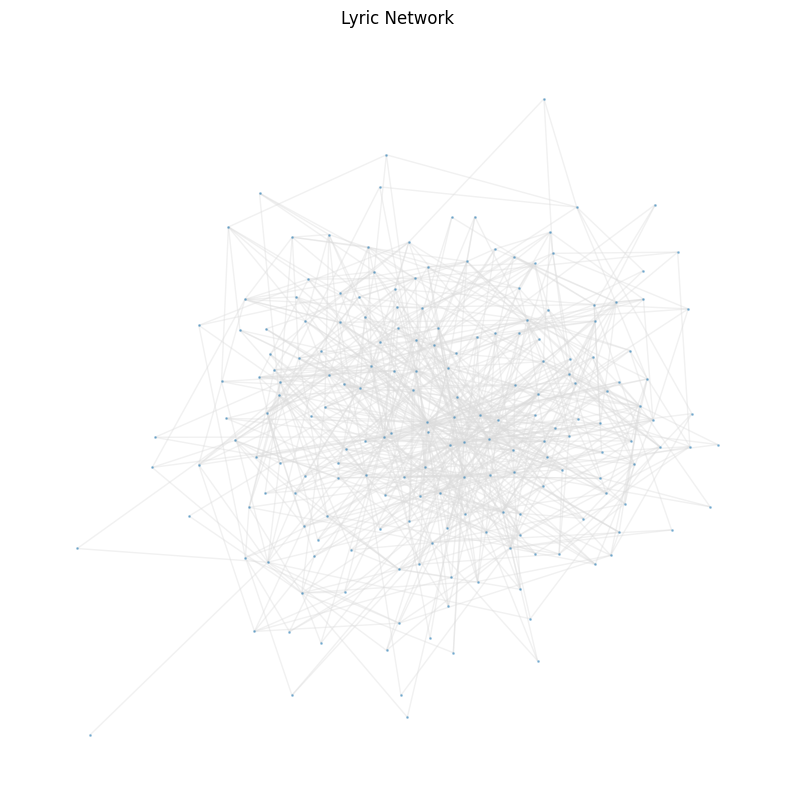

191 792


In [38]:
draw_net(G_lyric_subset)

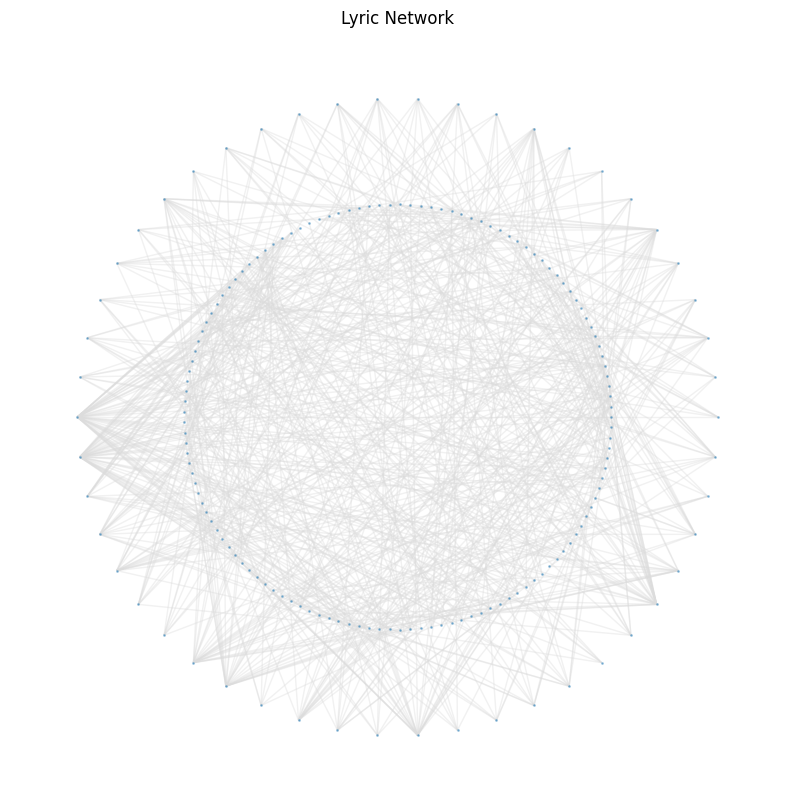

179 662


In [39]:
draw_net(G_words_subset, pos_type='shell')

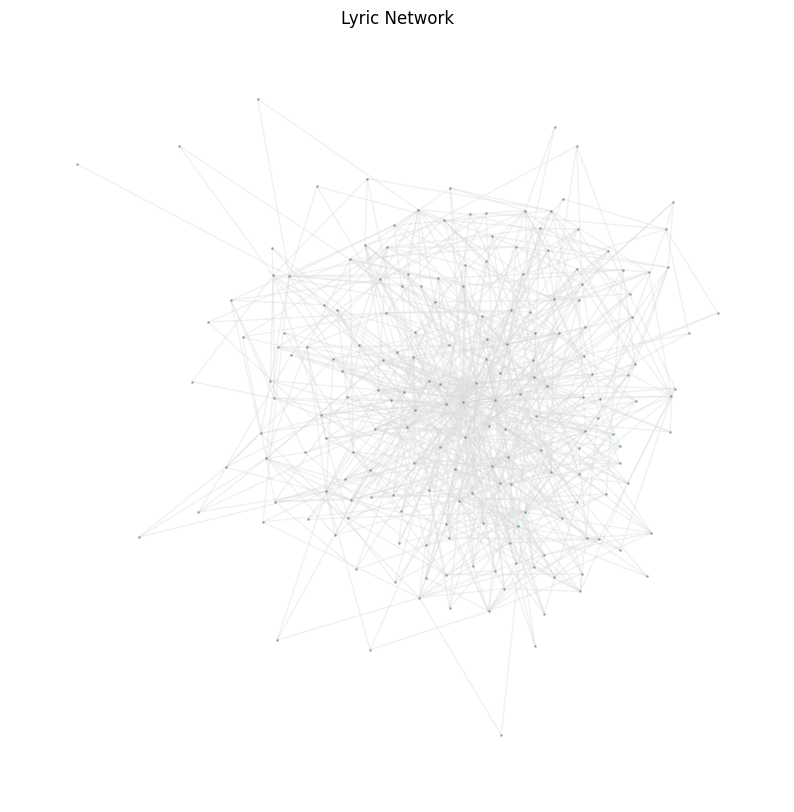

191 792


In [40]:
draw_net(G_lyric_subset)

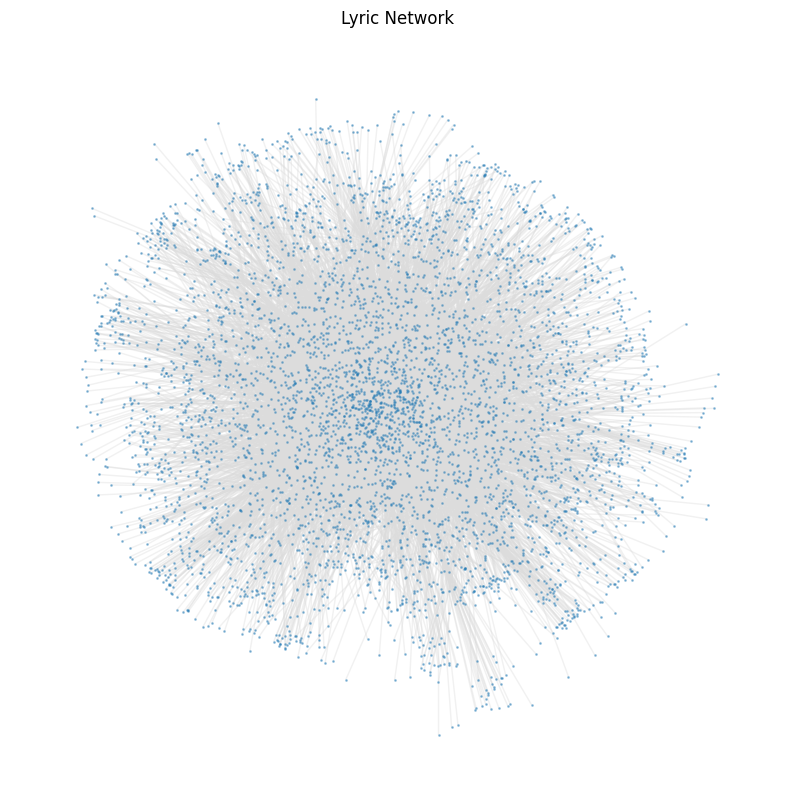

5046 13192


In [41]:
draw_net(G_lyric)

In [42]:
D_words_subset = {
    'nodes': list(G_words_subset.nodes()),
    'edges': list(G_words_subset.edges())}
with open('output/words_subset.json', 'w', encoding='utf-8') as f:
    json.dump(D_words_subset, f, ensure_ascii=False, indent=4)
